# EDA - Darija Translation Project


In [6]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [7]:
# Load the normal and gold shards
df_shard = pd.read_csv(f'../shards/gold/gold_shard_1.csv')
df_gold = pd.read_csv(f'../shards/silver/silver_shard_1.csv')

# Merge into single dataset (keep all rows, including overlaps for gold set)
df_eda = pd.concat([df_shard, df_gold], ignore_index=True)

# FIX: Handle broken IDs (e.g., "Wiki_Gen" used for all rows in Classes C/D)
# If we don't fix this, drop_duplicates(['id']) will delete all Class C/D data
bad_id_mask = df_eda['id'] == 'Wiki_Gen'
if bad_id_mask.sum() > 0:
    print(f"CRITICAL FIX: Found {bad_id_mask.sum()} rows with broken ID 'Wiki_Gen'.")
    print("   -> Regenerating unique IDs for these rows to prevent data loss.")
    # Create new IDs like Wiki_Gen_0001, Wiki_Gen_0002...
    new_ids = [f"Wiki_Gen_{i}" for i in range(bad_id_mask.sum())]
    df_eda.loc[bad_id_mask, 'id'] = new_ids

# Check for duplicates
duplicates = df_eda.duplicated(subset=['id']).sum()
print(f"CHARGEMENT - Shard 1")
print(f"   Normal Shard: {len(df_shard):,} lignes")
print(f"   Gold Set: {len(df_gold):,} lignes")
print(f"   Duplicates found: {duplicates}")
print(f"   Total: {len(df_eda):,} lignes")

if duplicates > 0:
    print("   WARNING: Found duplicates. Removing duplicates to ensure unique entries.")
    df_eda = df_eda.drop_duplicates(subset=['id']).reset_index(drop=True)
    print(f"   After deduplication: {len(df_eda):,} lignes")

print(f"\n[OK] Dataset: {len(df_eda):,} lignes")
print(f"[OK] Colonnes: {list(df_eda.columns)}")

# Add computed columns for analysis
df_eda['darija_len'] = df_eda['darija_arabic'].fillna('').str.len()
df_eda['english_len'] = df_eda['english'].fillna('').str.len()
df_eda['msa_len'] = df_eda['modern_standard_arabic'].fillna('').str.len()
df_eda['english_words'] = df_eda['english'].fillna('').str.split().str.len()
df_eda['arabizi_len'] = df_eda['darija_arabizi'].fillna('').str.len()

CHARGEMENT - Shard 1
   Normal Shard: 1,000 lignes
   Gold Set: 9,005 lignes
   Duplicates found: 0
   Total: 10,005 lignes

[OK] Dataset: 10,005 lignes
[OK] Colonnes: ['data_id', 'id', 'classe', 'darija_arabic', 'darija_arabizi', 'english', 'modern_standard_arabic', 'english_word_count', 'status']


DISTRIBUTION - Classes & Status

[1] DISTRIBUTION DES CLASSES:
   Classe A: 2,481 (24.8%)
   Classe B: 2,504 (25.0%)
   Classe C: 2,539 (25.4%)
   Classe D: 2,481 (24.8%)

[2] DISTRIBUTION DES STATUS:
   GENERATED: 7,512 (75.1%)
   PARTIALLY VALIDATED: 2,482 (24.8%)
   active: 11 (0.1%)


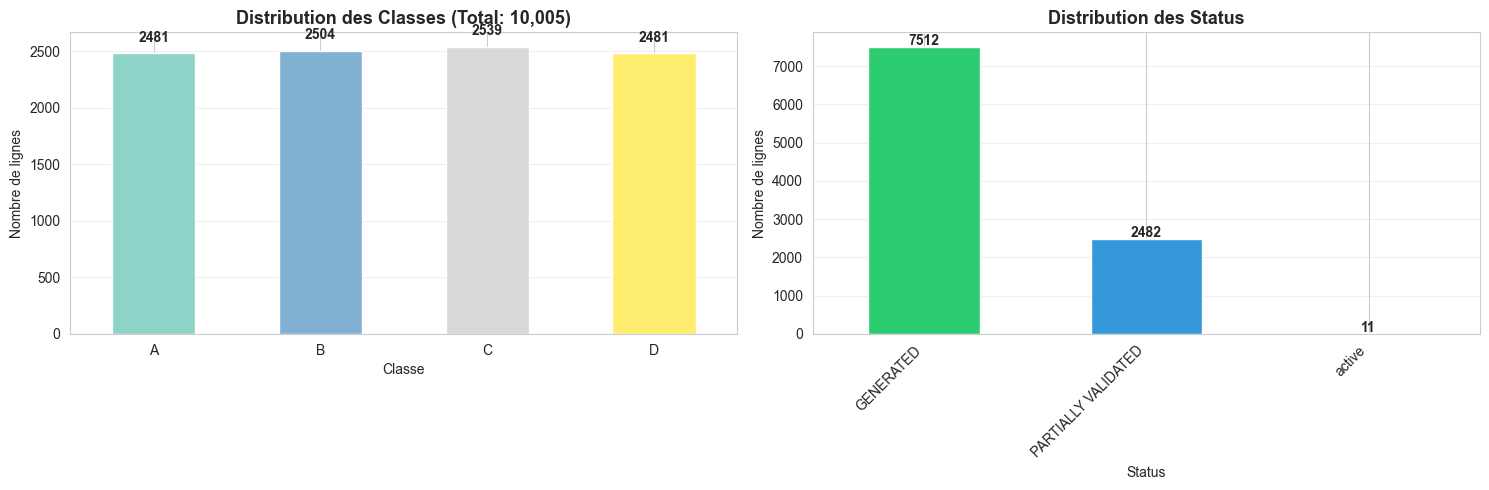

In [8]:
# Distribution Analysis - Classes and Status
print("DISTRIBUTION - Classes & Status")
print("=" * 100)

# Class distribution
class_dist = df_eda['classe'].value_counts().sort_index()
print("\n[1] DISTRIBUTION DES CLASSES:")
for cls, count in class_dist.items():
    pct = (count / len(df_eda)) * 100
    print(f"   Classe {cls}: {count:,} ({pct:.1f}%)")

# Status distribution
print("\n[2] DISTRIBUTION DES STATUS:")
status_dist = df_eda['status'].value_counts()
for status, count in status_dist.items():
    pct = (count / len(df_eda)) * 100
    print(f"   {status}: {count:,} ({pct:.1f}%)")

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Classes
colors_class = plt.cm.Set3(np.linspace(0, 1, len(class_dist)))
class_dist.plot(kind='bar', ax=axes[0], color=colors_class)
axes[0].set_title(f'Distribution des Classes (Total: {len(df_eda):,})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de lignes')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(class_dist.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold', fontsize=10)

# Status
colors_status = ['#2ecc71', '#3498db', '#e74c3c']
status_dist.plot(kind='bar', ax=axes[1], color=colors_status[:len(status_dist)])
axes[1].set_title('Distribution des Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Nombre de lignes')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(status_dist.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("=" * 100)

## Text Length Distribution

Examinez les distributions de longueur des textes pour chaque langue (Darija, English, Arabizi, MSA). Attendez une répartition normale confirmant la variété de la traduction.

STATISTIQUES DE LONGUEUR

DARIJA (caractères):
   Min: 6 | Max: 3775 | Mean: 125.8 | Median: 131.0 | Std: 80.6

ENGLISH (caractères):
   Min: 14 | Max: 1425 | Mean: 146.3 | Median: 152.0 | Std: 80.6

MSA (caractères):
   Min: 3 | Max: 2031 | Mean: 123.3 | Median: 128.0 | Std: 71.7

ARABIZI (caractères):
   Min: 7 | Max: 1409 | Mean: 136.1 | Median: 142.0 | Std: 75.3

ENGLISH (mots):
   Min: 5 | Max: 98 | Mean: 28.0 | Median: 30.0 | Std: 14.3


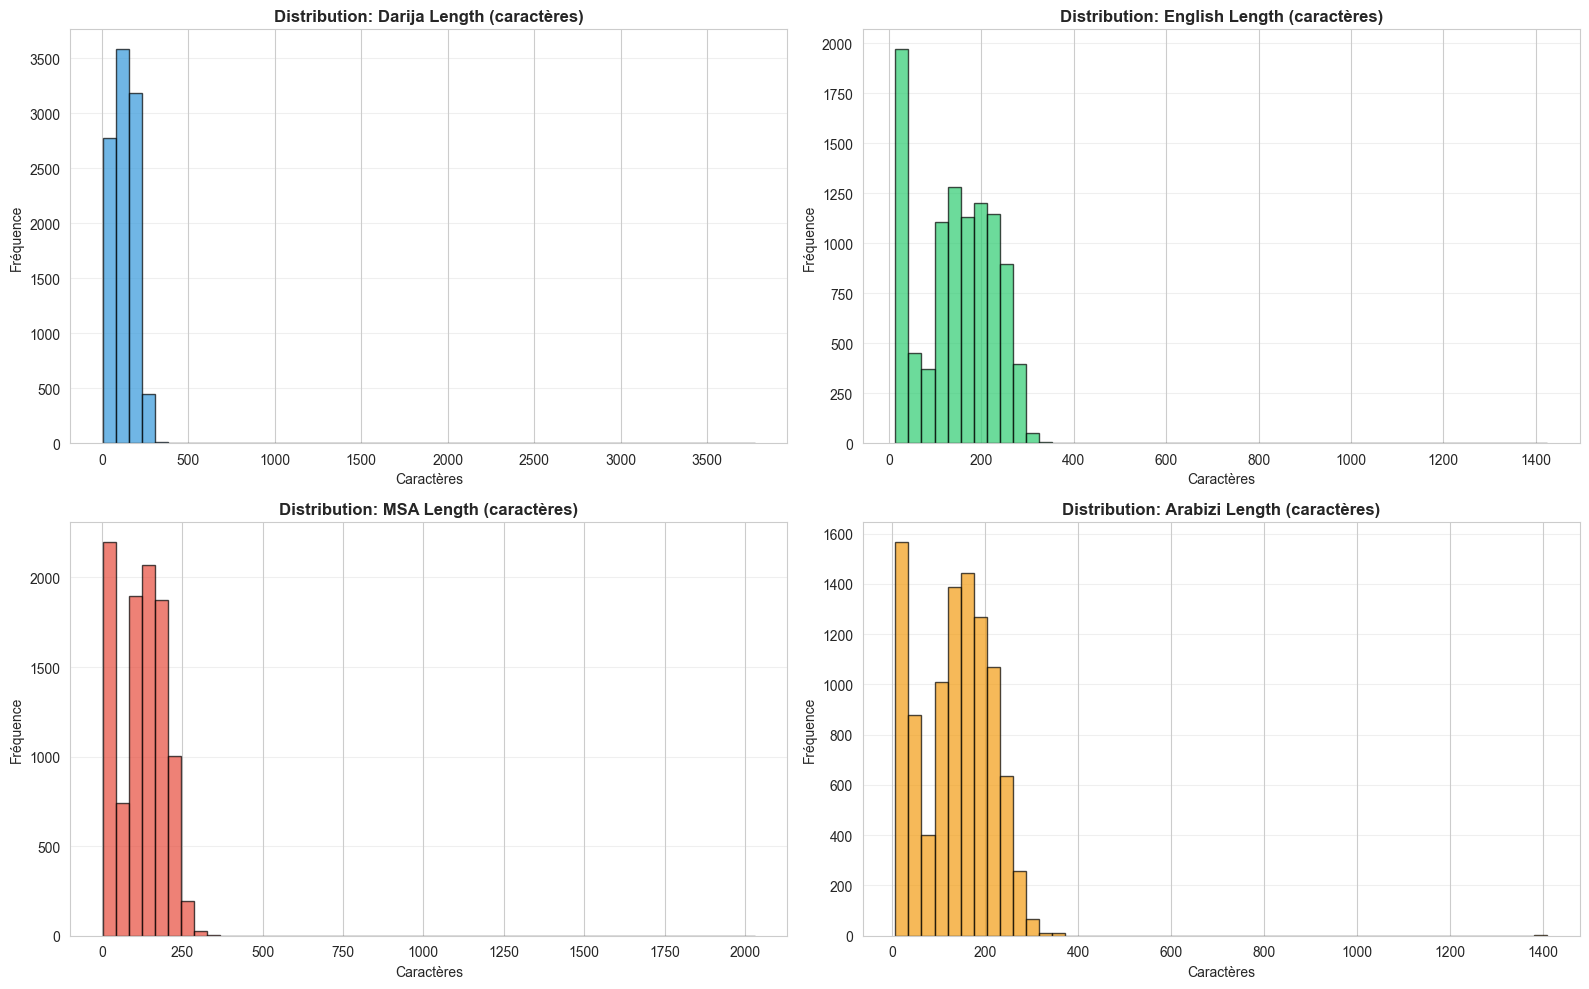

In [9]:
# Text Length Statistics
print("STATISTIQUES DE LONGUEUR")
print("=" * 100)

# Compute statistics
stats_cols = ['darija_len', 'english_len', 'msa_len', 'arabizi_len', 'english_words']
stats_display = ['DARIJA (caractères)', 'ENGLISH (caractères)', 'MSA (caractères)', 'ARABIZI (caractères)', 'ENGLISH (mots)']

for col_name, col_display in zip(stats_cols, stats_display):
    data = df_eda[col_name].dropna()
    print(f"\n{col_display}:")
    print(f"   Min: {data.min():.0f} | Max: {data.max():.0f} | Mean: {data.mean():.1f} | Median: {data.median():.1f} | Std: {data.std():.1f}")

# Visualize distributions - 4 subplots with KDE
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Darija length
axes[0, 0].hist(df_eda['darija_len'].dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution: Darija Length (caractères)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Caractères')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].grid(axis='y', alpha=0.3)

# English length
axes[0, 1].hist(df_eda['english_len'].dropna(), bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution: English Length (caractères)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Caractères')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].grid(axis='y', alpha=0.3)

# MSA length
axes[1, 0].hist(df_eda['msa_len'].dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution: MSA Length (caractères)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Caractères')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].grid(axis='y', alpha=0.3)

# Arabizi length
axes[1, 1].hist(df_eda['arabizi_len'].dropna(), bins=50, color='#f39c12', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Distribution: Arabizi Length (caractères)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Caractères')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 100)

## Text Length Correlations

Investiguez les corrélations entre les longueurs des textes dans différentes langues. Les corrélations positives indiquent une cohérence traductionnelle.

CORRELATIONS - Longueurs des Textes (Nettoyé des Outliers)


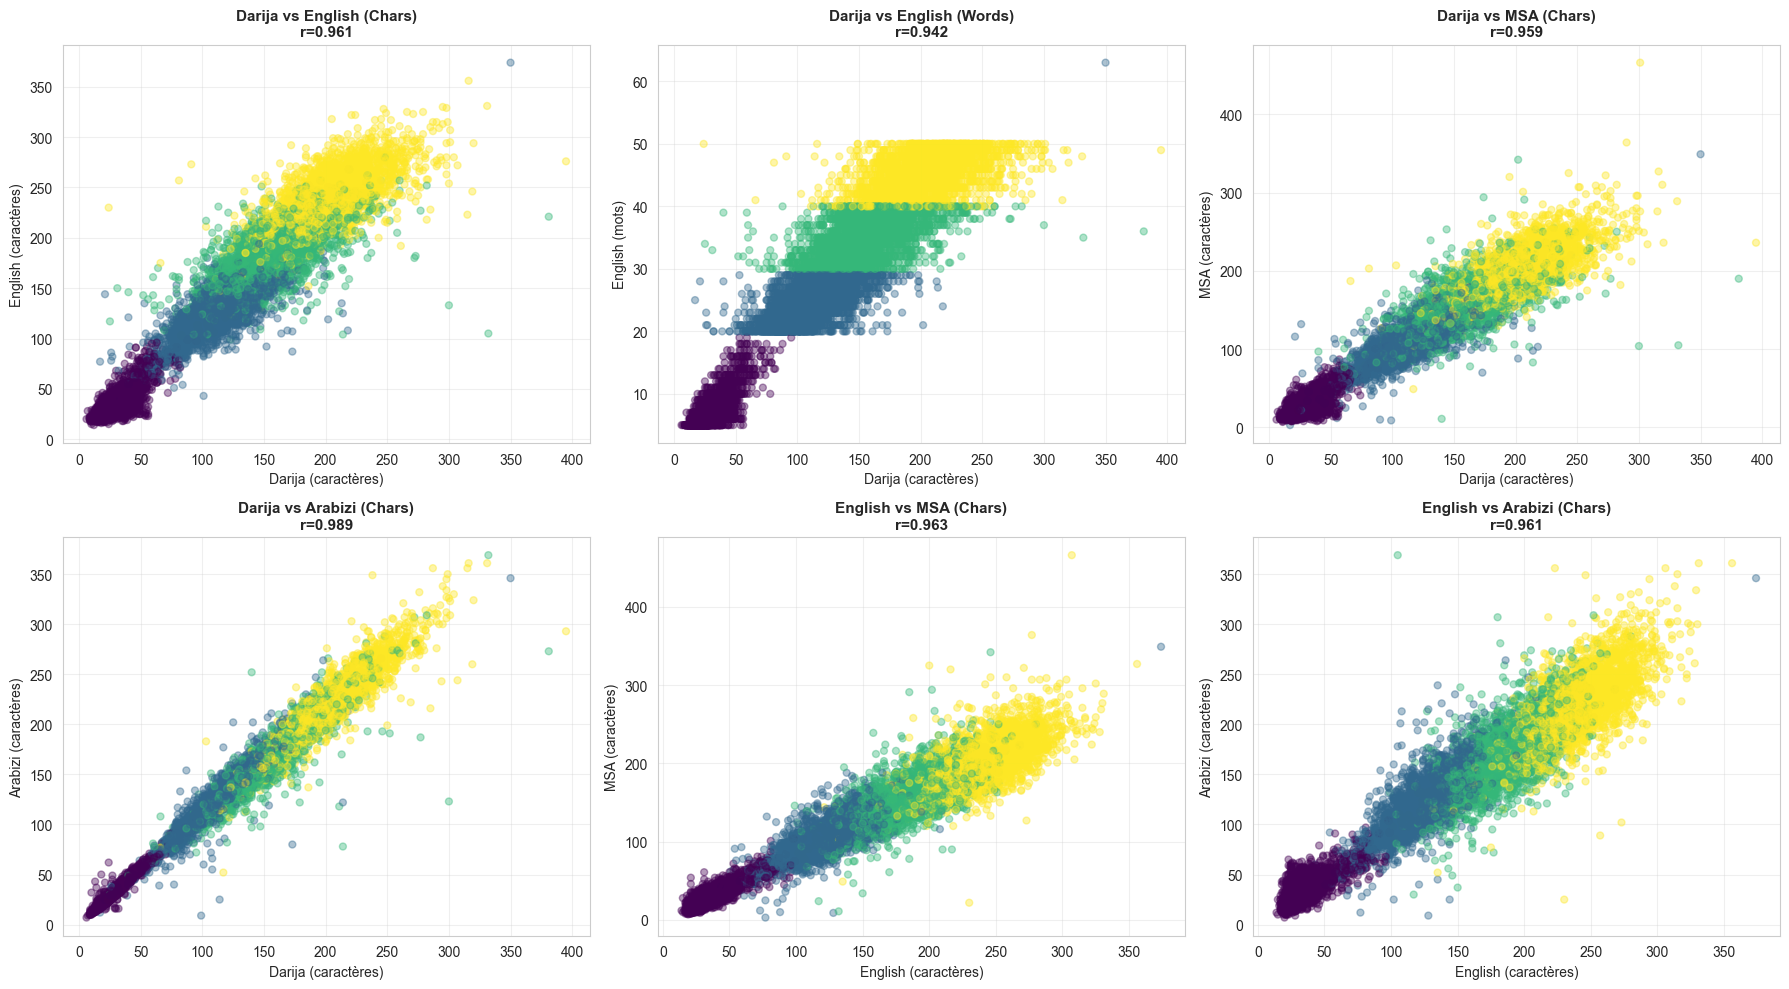


[OK] CORRELATIONS CALCULEES (Données filtrées):
   Darija <-> English (chars): 0.961 | Darija <-> English (words): 0.942
   Darija <-> MSA: 0.959 | Darija <-> Arabizi: 0.989
   English <-> MSA: 0.963 | English <-> Arabizi: 0.961

[LIST] REMOVED OUTLIERS (2 lines excluded from plots):


,id,classe,darija_len,english_len,msa_len,arabizi_len
244,wiki_2,B,2052,1425,2031,1409
7940,WIKI_D_12446,D,3775,242,197,206


In [10]:
# Scatter Plots - Text Length Relationships
print("CORRELATIONS - Longueurs des Textes (Nettoyé des Outliers)")
print("=" * 100)

# Identify extreme outliers that distort the visualization
# Thresholds based on previous analysis: 
# Darija/English/Arabizi > 1000 chars, MSA > 2000 chars
outlier_mask = (
    (df_eda['darija_len'] > 1000) | 
    (df_eda['english_len'] > 1000) | 
    (df_eda['msa_len'] > 2000) | 
    (df_eda['arabizi_len'] > 1000)
)

df_plot = df_eda[~outlier_mask].copy()
df_outliers = df_eda[outlier_mask].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Color by class
class_colors = df_plot['classe'].astype('category').cat.codes

# Helper for plotting
def plot_scatter(ax, x_col, y_col, x_label, y_label, title_prefix):
    corr = df_plot[[x_col, y_col]].corr().iloc[0, 1]
    ax.scatter(df_plot[x_col], df_plot[y_col], alpha=0.4, c=class_colors, cmap='viridis', s=25)
    ax.set_title(f'{title_prefix}\nr={corr:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(alpha=0.3)
    return corr

# 1. Darija vs English (chars)
corr_en_chars = plot_scatter(axes[0, 0], 'darija_len', 'english_len', 'Darija (caractères)', 'English (caractères)', 'Darija vs English (Chars)')

# 2. Darija vs English (words)
corr_en_words = plot_scatter(axes[0, 1], 'darija_len', 'english_words', 'Darija (caractères)', 'English (mots)', 'Darija vs English (Words)')

# 3. Darija vs MSA
corr_msa = plot_scatter(axes[0, 2], 'darija_len', 'msa_len', 'Darija (caractères)', 'MSA (caractères)', 'Darija vs MSA (Chars)')

# 4. Darija vs Arabizi
corr_arabizi = plot_scatter(axes[1, 0], 'darija_len', 'arabizi_len', 'Darija (caractères)', 'Arabizi (caractères)', 'Darija vs Arabizi (Chars)')

# 5. English vs MSA
corr_en_msa = plot_scatter(axes[1, 1], 'english_len', 'msa_len', 'English (caractères)', 'MSA (caractères)', 'English vs MSA (Chars)')

# 6. English vs Arabizi
corr_en_arabizi = plot_scatter(axes[1, 2], 'english_len', 'arabizi_len', 'English (caractères)', 'Arabizi (caractères)', 'English vs Arabizi (Chars)')

plt.tight_layout()
plt.show()

print(f"\n[OK] CORRELATIONS CALCULEES (Données filtrées):")
print(f"   Darija <-> English (chars): {corr_en_chars:.3f} | Darija <-> English (words): {corr_en_words:.3f}")
print(f"   Darija <-> MSA: {corr_msa:.3f} | Darija <-> Arabizi: {corr_arabizi:.3f}")
print(f"   English <-> MSA: {corr_en_msa:.3f} | English <-> Arabizi: {corr_en_arabizi:.3f}")

if len(df_outliers) > 0:
    print(f"\n[LIST] REMOVED OUTLIERS ({len(df_outliers)} lines excluded from plots):")
    display(df_outliers[['id', 'classe', 'darija_len', 'english_len', 'msa_len', 'arabizi_len']])
else:
    print("\n[OK] No outliers detected.")

print("=" * 100)

## Data Quality Assessment

Évaluez la complétude et la qualité des données. Vérifiez les valeurs manquantes, les champs vides et identifiez les problèmes de script (Arabic en Arabizi, Non-Arabic en Darija, etc.).

EVALUATION DE LA QUALITE

[1] VALEURS MANQUANTES:
   [OK] Aucune valeur manquante!

[2] CHAMPS VIDES:
   [OK] Aucun champ vide!


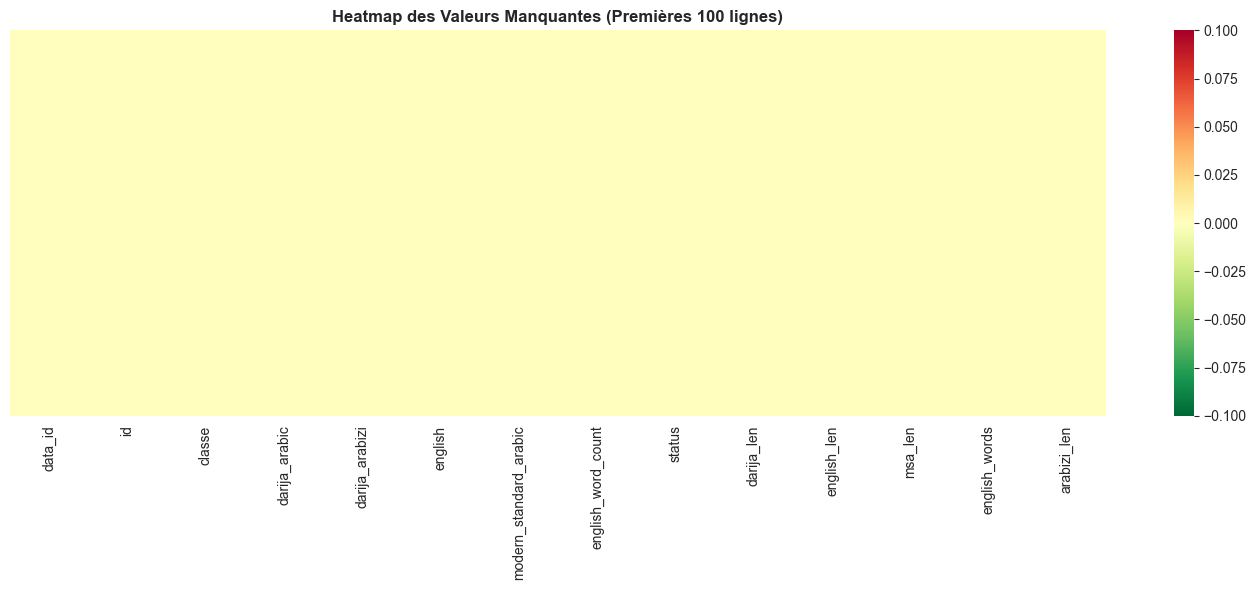

In [11]:
# Missing Values Analysis
print("EVALUATION DE LA QUALITE")
print("=" * 100)

# Missing values
missing_stats = df_eda.isnull().sum()
print("\n[1] VALEURS MANQUANTES:")
has_missing = False
for col in missing_stats[missing_stats > 0].index:
    pct = (missing_stats[col] / len(df_eda)) * 100
    print(f"   {col}: {missing_stats[col]} ({pct:.2f}%)")
    has_missing = True

if not has_missing:
    print("   [OK] Aucune valeur manquante!")

# Check for empty strings
print("\n[2] CHAMPS VIDES:")
empty_counts = {
    'darija_arabic': (df_eda['darija_arabic'].fillna('').str.len() == 0).sum(),
    'english': (df_eda['english'].fillna('').str.len() == 0).sum(),
    'darija_arabizi': (df_eda['darija_arabizi'].fillna('').str.len() == 0).sum(),
    'modern_standard_arabic': (df_eda['modern_standard_arabic'].fillna('').str.len() == 0).sum(),
}

has_empty = False
for col, count in empty_counts.items():
    if count > 0:
        pct = (count / len(df_eda)) * 100
        print(f"   {col}: {count} ({pct:.2f}%)")
        has_empty = True

if not has_empty:
    print("   [OK] Aucun champ vide!")

# Heatmap of missing values (first 100 rows)
fig, ax = plt.subplots(figsize=(14, 6))
missing_matrix = df_eda.isnull().astype(int)
sns.heatmap(missing_matrix.iloc[:100], cbar=True, cmap='RdYlGn_r', ax=ax, yticklabels=False)
ax.set_title('Heatmap des Valeurs Manquantes (Premières 100 lignes)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 100)

## Anomalies Detection & Problem Entries

Cette section identifie les lignes qui **doivent** être corrigées manuellement. Les problèmes incluent les erreurs de script (Arabic dans Arabizi), les traductions manquantes ou vides, et les incohérences de format.

In [12]:
# Problematic Entries Detection
print("DETECTION D'ANOMALIES")
print("=" * 100)

# Define patterns
arabic_pattern = re.compile(r'[\u0600-\u06FF]')
english_pattern = re.compile(r'[a-zA-Z]')

# Issue 1: Arabic in Arabizi (should be Latin only)
arabic_in_arabizi = df_eda[df_eda['darija_arabizi'].fillna('').str.contains(arabic_pattern, regex=True)]
print(f"\n[ISSUE 1] Arabic in Arabizi column (should be LATIN)")
print(f"   Count: {len(arabic_in_arabizi)} ({len(arabic_in_arabizi)/len(df_eda)*100:.2f}%)")
if len(arabic_in_arabizi) > 0:
    print(f"   Examples:")
    for idx, row in arabic_in_arabizi.head(2).iterrows():
        arabizi_preview = str(row['darija_arabizi'])[:60]
        print(f"   - ID: {row['id']} | {arabizi_preview}...")

# Issue 2: Non-Arabic in Darija (should be Arabic)
non_arabic_darija = df_eda[~df_eda['darija_arabic'].fillna('').str.contains(arabic_pattern, regex=True)]
non_arabic_darija = non_arabic_darija[non_arabic_darija['darija_arabic'].fillna('').str.len() > 0]
print(f"\n[ISSUE 2] Non-Arabic in Darija column (should be ARABIC)")
print(f"   Count: {len(non_arabic_darija)} ({len(non_arabic_darija)/len(df_eda)*100:.2f}%)")
if len(non_arabic_darija) > 0:
    print(f"   Examples:")
    for idx, row in non_arabic_darija.head(2).iterrows():
        darija_preview = str(row['darija_arabic'])[:60]
        print(f"   - ID: {row['id']} | {darija_preview}...")

# Issue 3: Arabic in English
arabic_in_english = df_eda[df_eda['english'].fillna('').str.contains(arabic_pattern, regex=True)]
print(f"\n[ISSUE 3] Arabic in English column (should be LATIN)")
print(f"   Count: {len(arabic_in_english)} ({len(arabic_in_english)/len(df_eda)*100:.2f}%)")
if len(arabic_in_english) > 0:
    print(f"   Examples:")
    for idx, row in arabic_in_english.head(2).iterrows():
        eng_preview = str(row['english'])[:60]
        print(f"   - ID: {row['id']} | {eng_preview}...")

# Issue 4: Empty/Missing translations
empty_english = (df_eda['english'].fillna('').str.len() == 0).sum()
empty_msa = (df_eda['modern_standard_arabic'].fillna('').str.len() == 0).sum()
empty_darija = (df_eda['darija_arabic'].fillna('').str.len() == 0).sum()
print(f"\n[ISSUE 4] Missing/Empty translations")
print(f"   Empty Darija: {empty_darija} ({empty_darija/len(df_eda)*100:.2f}%)")
print(f"   Empty English: {empty_english} ({empty_english/len(df_eda)*100:.2f}%)")
print(f"   Empty MSA: {empty_msa} ({empty_msa/len(df_eda)*100:.2f}%)")

# Total problematic
total_issues = len(arabic_in_arabizi) + len(non_arabic_darija) + len(arabic_in_english) + empty_english + empty_msa + empty_darija
print(f"\nSUMMARY:")
print(f"   Total problematic rows: {total_issues} ({total_issues/len(df_eda)*100:.2f}%)")
print("=" * 100)

DETECTION D'ANOMALIES


ArrowInvalid: Invalid regular expression: invalid escape sequence: \u


ANOMALY VISUALIZATION


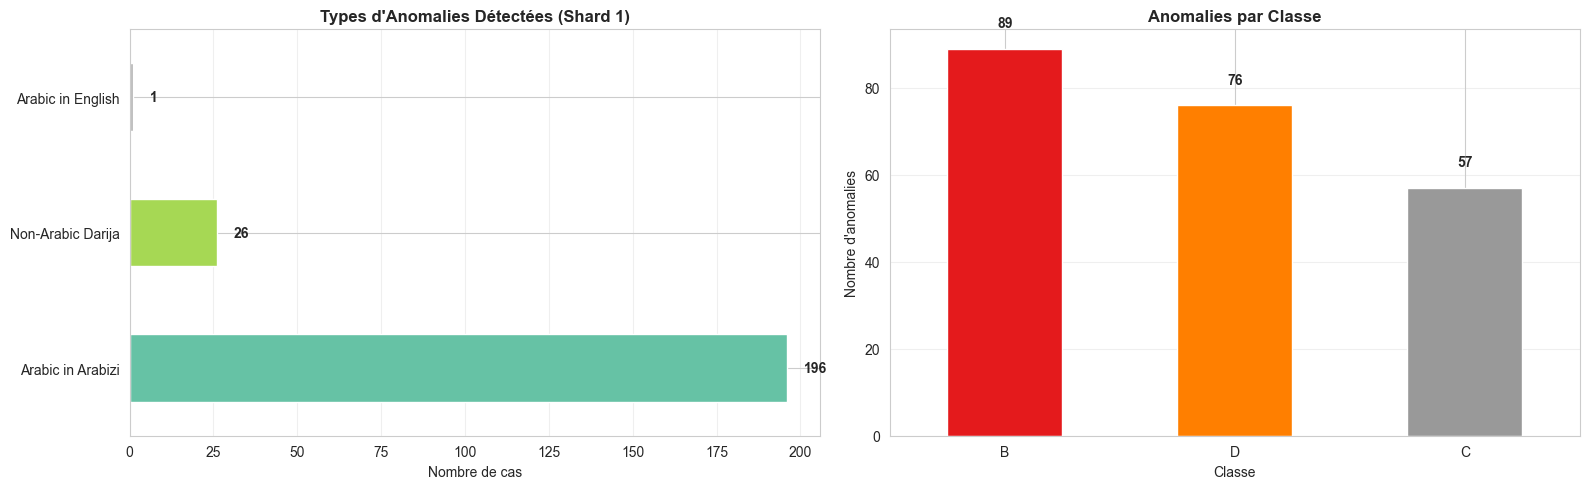


PROBLEMATIC ENTRIES (222 rows):


,Issues,ID,Classe,Status
0,Arabic in Arabizi,WIKI_C_10914,C,GENERATED
1,Arabic in Arabizi,WIKI_C_08163,C,GENERATED
2,Arabic in Arabizi,WIKI_D_07266,D,GENERATED
3,Arabic in Arabizi,DATA_13721,B,GENERATED
4,Arabic in Arabizi,WIKI_D_08786,D,GENERATED
5,Arabic in Arabizi,DATA_18580,B,GENERATED
6,Arabic in Arabizi,WIKI_C_11676,C,GENERATED
7,Arabic in Arabizi,WIKI_C_02723,C,GENERATED
8,Arabic in Arabizi,DATA_16782,B,GENERATED
9,Non-Arabic Darija,DATA_24623,B,GENERATED


In [ ]:
# Visualization of Anomalies
print("\nANOMALY VISUALIZATION")

# Collect all issues
issues_data = []
for idx, row in df_eda.iterrows():
    issues = []
    
    # Check for Arabic in Arabizi
    arabizi = str(row.get('darija_arabizi', ''))
    if arabizi and arabic_pattern.search(arabizi):
        issues.append('Arabic in Arabizi')
    
    # Check for non-Arabic Darija
    darija = str(row.get('darija_arabic', ''))
    if darija and len(darija) > 0 and not arabic_pattern.search(darija):
        issues.append('Non-Arabic Darija')
    
    # Check for Arabic in English
    eng = str(row.get('english', ''))
    if eng and arabic_pattern.search(eng):
        issues.append('Arabic in English')
    
    # Check for empty translations
    if len(darija.strip()) == 0:
        issues.append('Empty Darija')
    if len(eng.strip()) == 0:
        issues.append('Empty English')
    
    msa = str(row.get('modern_standard_arabic', ''))
    if len(msa.strip()) == 0:
        issues.append('Empty MSA')
    
    if issues:
        issues_data.append({
            'Issues': ', '.join(issues),
            'ID': row['id'],
            'Classe': row['classe'],
            'Status': row['status']
        })

issues_df = pd.DataFrame(issues_data)

if len(issues_df) > 0:
    # Count issue types
    all_issues = []
    for issue_str in issues_df['Issues']:
        all_issues.extend([i.strip() for i in issue_str.split(',')])
    
    issue_counts = pd.Series(all_issues).value_counts()
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Issue counts bar chart
    colors_issues = plt.cm.Set2(np.linspace(0, 1, len(issue_counts)))
    issue_counts.plot(kind='barh', ax=axes[0], color=colors_issues)
    axes[0].set_title(f'Types d\'Anomalies Détectées (Shard {SHARD_NUM})', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Nombre de cas')
    axes[0].grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(issue_counts.values):
        axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')
    
    # Distribution by class
    class_issues = issues_df['Classe'].value_counts()
    colors_class = plt.cm.Set1(np.linspace(0, 1, len(class_issues)))
    class_issues.plot(kind='bar', ax=axes[1], color=colors_class)
    axes[1].set_title('Anomalies par Classe', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Classe')
    axes[1].set_ylabel('Nombre d\'anomalies')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(class_issues.values):
        axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Display problematic rows table
    print(f"\nPROBLEMATIC ENTRIES ({len(issues_df)} rows):")
    print("=" * 120)
    display(issues_df.head(20))
else:
    print("\n[OK] NO ISSUES DETECTED!")